## Imports and Essentials ##

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

## Settings and Constants ##

In [3]:
RANDOM_STATE = 77
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

DATA_PATH = Path("hospital-data.csv")

## Load Data ##

In [4]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (6388, 74)


,caseid,subjectid,casestart,caseend,anestart,aneend,opstart,opend,adm,dis,icu_days,death_inhosp,age,sex,height,weight,bmi,asa,emop,department,optype,dx,opname,approach,position,ane_type,preop_htn,preop_dm,preop_ecg,preop_pft,preop_hb,preop_plt,preop_pt,preop_aptt,preop_na,preop_k,preop_gluc,preop_alb,preop_ast,preop_alt,preop_bun,preop_cr,preop_ph,preop_hco3,preop_be,preop_pao2,preop_paco2,preop_sao2,cormack,airway,tubesize,dltubesize,lmasize,iv1,iv2,aline1,aline2,cline1,cline2,intraop_ebl,intraop_uo,intraop_rbc,intraop_ffp,intraop_crystalloid,intraop_colloid,intraop_ppf,intraop_mdz,intraop_ftn,intraop_rocu,intraop_vecu,intraop_eph,intraop_phe,intraop_epi,intraop_ca
0,1,5955,0,11542,-552,10848.0,1668,10368,-236220,627780,0,0,77.0,M,160.2,67.5,26.3,2.0,0,General surgery,Colorectal,Rectal cancer,Low anterior resection,Open,Lithotomy,General,1,0,Normal Sinus Rhythm,Normal,14.1,189.0,94.0,33.2,141.0,3.1,134.0,4.3,18.0,16.0,10.0,0.82,NaN,NaN,NaN,NaN,NaN,NaN,I,Oral,7.5,NaN,NaN,Right forearm,NaN,Left radial,NaN,NaN,NaN,NaN,300.0,0,0,350.0,0,120,0.0,100,70,0,10,0,0,0
1,2,2487,0,15741,-1039,14921.0,1721,14621,-221160,1506840,0,0,54.0,M,167.3,54.8,19.6,2.0,0,General surgery,Stomach,Advanced gastric cancer,Subtotal gastrectomy,Open,Supine,General,0,0,Normal Sinus Rhythm,Normal,10.2,251.0,110.0,31.9,143.0,4.7,88.0,3.8,18.0,15.0,14.0,0.86,NaN,NaN,NaN,NaN,NaN,NaN,I,Oral,7.5,NaN,NaN,Left forearm,NaN,NaN,NaN,NaN,NaN,50.0,700.0,0,0,800.0,0,150,0.0,0,100,0,20,0,0,0
2,3,2861,0,4394,-590,4210.0,1090,3010,-218640,40560,0,0,62.0,M,169.1,69.7,24.4,1.0,0,General surgery,Biliary/Pancreas,Gallbladder stone,Cholecystectomy,Videoscopic,Reverse Trendelenburg,General,0,0,Normal Sinus Rhythm,Normal,14.2,373.0,103.0,30.3,144.0,4.9,87.0,4.2,17.0,34.0,14.0,1.18,NaN,NaN,NaN,NaN,NaN,NaN,I,Oral,7.5,NaN,NaN,Left forearm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,200.0,0,0,0.0,0,50,0,0,0,0,0
3,4,1903,0,20990,-778,20222.0,2522,17822,-201120,576480,1,0,74.0,M,160.6,53.0,20.5,2.0,0,General surgery,Stomach,Advanced gastric cancer,Distal gastrectomy,Videoscopic,Reverse Trendelenburg,General,1,0,Normal Sinus Rhythm,Normal,14.4,275.0,103.0,34.5,141.0,4.2,108.0,4.1,23.0,18.0,10.0,0.96,NaN,NaN,NaN,NaN,NaN,NaN,I,Oral,NaN,NaN,NaN,Left forearm,NaN,Right radial,NaN,NaN,NaN,NaN,270.0,0,0,2700.0,0,80,0.0,100,100,0,50,0,0,0
4,5,4416,0,21531,-1009,22391.0,2591,20291,-67560,3734040,13,0,66.0,M,171.0,59.7,20.4,3.0,1,General surgery,Vascular,Aortic aneurysm,Aneurysmal repair,Open,Prone,General,1,0,Left anterior fascicular block,Normal,10.1,67.0,73.0,36.5,146.0,4.4,126.0,2.6,765.0,77.0,50.0,4.43,NaN,NaN,NaN,NaN,NaN,NaN,I,Oral,7.5,NaN,NaN,Right forearm,NaN,Right radial,NaN,Right IJV,NaN,2600.0,1490.0,8,8,7100.0,0,0,0.0,0,160,0,10,900,0,2100


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6388 entries, 0 to 6387
Data columns (total 74 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   caseid               6388 non-null   int64  
 1   subjectid            6388 non-null   int64  
 2   casestart            6388 non-null   int64  
 3   caseend              6388 non-null   int64  
 4   anestart             6388 non-null   int64  
 5   aneend               6388 non-null   float64
 6   opstart              6388 non-null   int64  
 7   opend                6388 non-null   int64  
 8   adm                  6388 non-null   int64  
 9   dis                  6388 non-null   int64  
 10  icu_days             6388 non-null   int64  
 11  death_inhosp         6388 non-null   int64  
 12  age                  6388 non-null   float64
 13  sex                  6388 non-null   object 
 14  height               6388 non-null   float64
 15  weight               6388 non-null   f

## Basic Cleaning and Processing Operations ##

In [13]:
target_col = "death_inhosp"

if target_col not in df.columns:
    raise ValueError(f"{target_col} not found in columns: {df.columns.tolist()}")

df[target_col].value_counts(dropna=False)

death_inhosp
0    6331
1      57
Name: count, dtype: int64

In [14]:
df = df.dropna(subset=[target_col])
df[target_col].value_counts(normalize=True)

death_inhosp
0    0.991077
1    0.008923
Name: proportion, dtype: float64

## Remove non-helpful columns ##

In [15]:
id_cols = [
    "caseid",
    "subjectid",
]

time_cols = [
    "casestart", "caseend",
    "anestart", "aneend",
    "opstart", "opend",
    "adm", "dis"
]

# this represents serious data leakage for our purposes we must remove
postop_outcome_cols = [
    "icu_days",
]

intraop_prefixes = [
    "intraop_",
]

airway_and_line_cols = [
    "cormack",
    "airway",
    "tubesize",
    "dltubesize",
    "lmasize",
    "iv1","iv2",
    "aline1","aline2",
    "cline1","cline2",
]

cols_to_drop = set(id_cols + time_cols + postop_outcome_cols + airway_and_line_cols)

for c in df.columns:
    if any(c.startswith(p) for p in intraop_prefixes):
        cols_to_drop.add(c)

cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df_clean = df.drop(columns=cols_to_drop)
df_clean

,death_inhosp,age,sex,height,weight,bmi,asa,emop,department,optype,dx,opname,approach,position,ane_type,preop_htn,preop_dm,preop_ecg,preop_pft,preop_hb,preop_plt,preop_pt,preop_aptt,preop_na,preop_k,preop_gluc,preop_alb,preop_ast,preop_alt,preop_bun,preop_cr,preop_ph,preop_hco3,preop_be,preop_pao2,preop_paco2,preop_sao2
0,0,77.0,M,160.2,67.50,26.3,2.0,0,General surgery,Colorectal,Rectal cancer,Low anterior resection,Open,Lithotomy,General,1,0,Normal Sinus Rhythm,Normal,14.1,189.0,94.0,33.2,141.0,3.1,134.0,4.3,18.0,16.0,10.0,0.82,NaN,NaN,NaN,NaN,NaN,NaN
1,0,54.0,M,167.3,54.80,19.6,2.0,0,General surgery,Stomach,Advanced gastric cancer,Subtotal gastrectomy,Open,Supine,General,0,0,Normal Sinus Rhythm,Normal,10.2,251.0,110.0,31.9,143.0,4.7,88.0,3.8,18.0,15.0,14.0,0.86,NaN,NaN,NaN,NaN,NaN,NaN
2,0,62.0,M,169.1,69.70,24.4,1.0,0,General surgery,Biliary/Pancreas,Gallbladder stone,Cholecystectomy,Videoscopic,Reverse Trendelenburg,General,0,0,Normal Sinus Rhythm,Normal,14.2,373.0,103.0,30.3,144.0,4.9,87.0,4.2,17.0,34.0,14.0,1.18,NaN,NaN,NaN,NaN,NaN,NaN
3,0,74.0,M,160.6,53.00,20.5,2.0,0,General surgery,Stomach,Advanced gastric cancer,Distal gastrectomy,Videoscopic,Reverse Trendelenburg,General,1,0,Normal Sinus Rhythm,Normal,14.4,275.0,103.0,34.5,141.0,4.2,108.0,4.1,23.0,18.0,10.0,0.96,NaN,NaN,NaN,NaN,NaN,NaN
4,0,66.0,M,171.0,59.70,20.4,3.0,1,General surgery,Vascular,Aortic aneurysm,Aneurysmal repair,Open,Prone,General,1,0,Left anterior fascicular block,Normal,10.1,67.0,73.0,36.5,146.0,4.4,126.0,2.6,765.0,77.0,50.0,4.43,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6383,0,64.0,M,161.5,63.00,24.2,1.0,0,General surgery,Stomach,Advanced gastric cancer,Total gastrectomy,Open,Supine,General,0,0,Normal Sinus Rhythm,Normal,14.5,279.0,109.0,31.0,NaN,NaN,100.0,4.2,31.0,33.0,13.0,0.99,NaN,NaN,NaN,NaN,NaN,NaN
6384,0,69.0,M,159.3,62.30,24.6,2.0,0,General surgery,Colorectal,"Colon submucosal tumor, unknown behavior",Ultralow anterior resection,Videoscopic,Lithotomy,General,1,0,Normal Sinus Rhythm,Normal,15.2,239.0,114.0,28.7,144.0,4.0,140.0,3.7,18.0,28.0,19.0,0.84,NaN,NaN,NaN,NaN,NaN,NaN
6385,0,61.0,F,151.7,43.25,18.8,1.0,0,General surgery,Stomach,Early gastric cancer,Distal gastrectomy,Videoscopic,Supine,General,0,0,Normal Sinus Rhythm,Normal,12.6,276.0,97.0,29.2,140.0,4.5,103.0,4.8,20.0,19.0,15.0,0.66,NaN,NaN,NaN,NaN,NaN,NaN
6386,0,24.0,F,155.7,55.50,22.9,1.0,0,General surgery,Biliary/Pancreas,Common bile duct stone without obstruction,Choledochal cyst excision,Robotic,Supine,General,0,0,Normal Sinus Rhythm,Normal,12.5,214.0,90.0,32.2,142.0,3.6,95.0,4.4,16.0,10.0,7.0,0.65,NaN,NaN,NaN,NaN,NaN,NaN


## Get rid of the Junk Data ##

In [16]:
df_clean = df_clean.copy()

if "age" in df_clean.columns:
    df_clean = df_clean[(df_clean["age"] >= 18) & (df_clean["age"] <= 100)]

if "bmi" in df_clean.columns:
    df_clean = df_clean[(df_clean["bmi"] >= 10) & (df_clean["bmi"] <= 60)]

df_clean

,death_inhosp,age,sex,height,weight,bmi,asa,emop,department,optype,dx,opname,approach,position,ane_type,preop_htn,preop_dm,preop_ecg,preop_pft,preop_hb,preop_plt,preop_pt,preop_aptt,preop_na,preop_k,preop_gluc,preop_alb,preop_ast,preop_alt,preop_bun,preop_cr,preop_ph,preop_hco3,preop_be,preop_pao2,preop_paco2,preop_sao2
0,0,77.0,M,160.2,67.50,26.3,2.0,0,General surgery,Colorectal,Rectal cancer,Low anterior resection,Open,Lithotomy,General,1,0,Normal Sinus Rhythm,Normal,14.1,189.0,94.0,33.2,141.0,3.1,134.0,4.3,18.0,16.0,10.0,0.82,NaN,NaN,NaN,NaN,NaN,NaN
1,0,54.0,M,167.3,54.80,19.6,2.0,0,General surgery,Stomach,Advanced gastric cancer,Subtotal gastrectomy,Open,Supine,General,0,0,Normal Sinus Rhythm,Normal,10.2,251.0,110.0,31.9,143.0,4.7,88.0,3.8,18.0,15.0,14.0,0.86,NaN,NaN,NaN,NaN,NaN,NaN
2,0,62.0,M,169.1,69.70,24.4,1.0,0,General surgery,Biliary/Pancreas,Gallbladder stone,Cholecystectomy,Videoscopic,Reverse Trendelenburg,General,0,0,Normal Sinus Rhythm,Normal,14.2,373.0,103.0,30.3,144.0,4.9,87.0,4.2,17.0,34.0,14.0,1.18,NaN,NaN,NaN,NaN,NaN,NaN
3,0,74.0,M,160.6,53.00,20.5,2.0,0,General surgery,Stomach,Advanced gastric cancer,Distal gastrectomy,Videoscopic,Reverse Trendelenburg,General,1,0,Normal Sinus Rhythm,Normal,14.4,275.0,103.0,34.5,141.0,4.2,108.0,4.1,23.0,18.0,10.0,0.96,NaN,NaN,NaN,NaN,NaN,NaN
4,0,66.0,M,171.0,59.70,20.4,3.0,1,General surgery,Vascular,Aortic aneurysm,Aneurysmal repair,Open,Prone,General,1,0,Left anterior fascicular block,Normal,10.1,67.0,73.0,36.5,146.0,4.4,126.0,2.6,765.0,77.0,50.0,4.43,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6383,0,64.0,M,161.5,63.00,24.2,1.0,0,General surgery,Stomach,Advanced gastric cancer,Total gastrectomy,Open,Supine,General,0,0,Normal Sinus Rhythm,Normal,14.5,279.0,109.0,31.0,NaN,NaN,100.0,4.2,31.0,33.0,13.0,0.99,NaN,NaN,NaN,NaN,NaN,NaN
6384,0,69.0,M,159.3,62.30,24.6,2.0,0,General surgery,Colorectal,"Colon submucosal tumor, unknown behavior",Ultralow anterior resection,Videoscopic,Lithotomy,General,1,0,Normal Sinus Rhythm,Normal,15.2,239.0,114.0,28.7,144.0,4.0,140.0,3.7,18.0,28.0,19.0,0.84,NaN,NaN,NaN,NaN,NaN,NaN
6385,0,61.0,F,151.7,43.25,18.8,1.0,0,General surgery,Stomach,Early gastric cancer,Distal gastrectomy,Videoscopic,Supine,General,0,0,Normal Sinus Rhythm,Normal,12.6,276.0,97.0,29.2,140.0,4.5,103.0,4.8,20.0,19.0,15.0,0.66,NaN,NaN,NaN,NaN,NaN,NaN
6386,0,24.0,F,155.7,55.50,22.9,1.0,0,General surgery,Biliary/Pancreas,Common bile duct stone without obstruction,Choledochal cyst excision,Robotic,Supine,General,0,0,Normal Sinus Rhythm,Normal,12.5,214.0,90.0,32.2,142.0,3.6,95.0,4.4,16.0,10.0,7.0,0.65,NaN,NaN,NaN,NaN,NaN,NaN


## Seperating out the features and the target ##

In [17]:
y = df_clean[target_col].astype(int)
X = df_clean.drop(columns=[target_col])

print("Feature shape:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True))

Feature shape: (6331, 36)
Target distribution:
 death_inhosp
0    0.991786
1    0.008214
Name: proportion, dtype: float64


In [18]:
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

## Hand and Process missing values ##

We do median imputation and scaling for Numerical values

We do OHE and add a missing category for Categorical values

In [19]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

## Define the TTS Split stratified by mortality ##

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train.shape, X_test.shape

((5064, 36), (1267, 36))

## Baseline defined by LR ##

Our baseline model will be Logistic Regression as it is lightweight and easily interpretable

In [22]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1,
    solver="lbfgs"
)

log_reg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf", log_reg)
    ]
)

## We perform cross-validation on the training data ##

In [23]:
cv_results_logreg = cross_validate(
    log_reg_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=["roc_auc", "accuracy", "f1"],
    n_jobs=-1,
    return_train_score=False
)

pd.DataFrame(cv_results_logreg).agg(["mean", "std"]).T

,mean,std
fit_time,0.063506,0.005240
score_time,0.013993,0.000501
test_roc_auc,0.637375,0.111801
test_accuracy,0.926340,0.012758
test_f1,0.058167,0.032769


## We fit on the full training data and evaluate on the test set ##

In [24]:
log_reg_pipeline.fit(X_train, y_train)

y_proba_logreg = log_reg_pipeline.predict_proba(X_test)[:, 1]
y_pred_logreg = (y_proba_logreg >= 0.5).astype(int)

print("Logistic Regression Test ROC-AUC:", roc_auc_score(y_test, y_proba_logreg))
print("Logistic Regression Test Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Logistic Regression Test F1:", f1_score(y_test, y_pred_logreg))

print("\nConfusion matrix (LogReg):")
print(confusion_matrix(y_test, y_pred_logreg))

print("\nClassification report (LogReg):")
print(classification_report(y_test, y_pred_logreg))

Logistic Regression Test ROC-AUC: 0.7967382657120128
Logistic Regression Test Accuracy: 0.914759273875296
Logistic Regression Test F1: 0.06896551724137931

Confusion matrix (LogReg):
[[1155  102]
 [   6    4]]

Classification report (LogReg):
              precision    recall  f1-score   support

           0       0.99      0.92      0.96      1257
           1       0.04      0.40      0.07        10

    accuracy                           0.91      1267
   macro avg       0.52      0.66      0.51      1267
weighted avg       0.99      0.91      0.95      1267



## We plot outcomes and Precision Recall curves for our LR ##

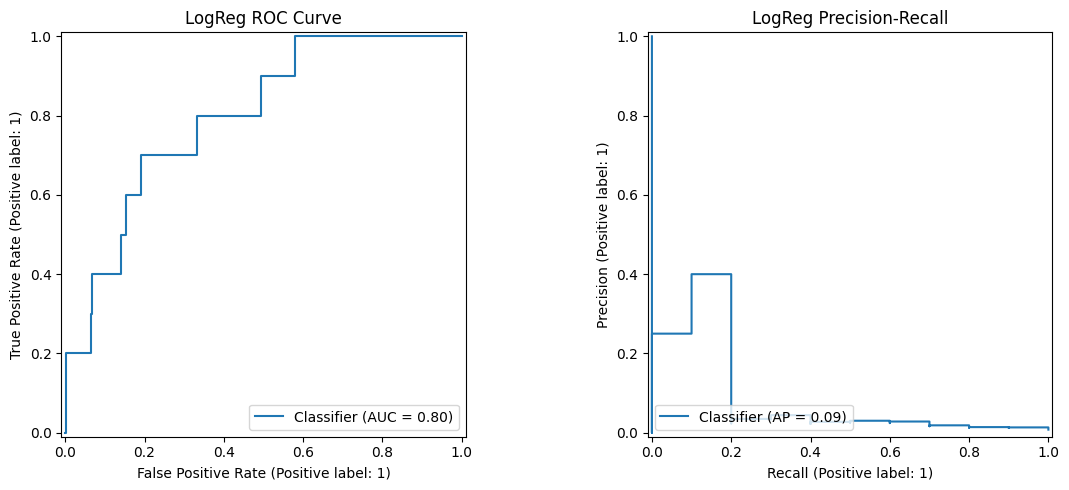

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, y_proba_logreg, ax=ax[0])
ax[0].set_title("LogReg ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_proba_logreg, ax=ax[1])
ax[1].set_title("LogReg Precision-Recall")

plt.tight_layout()
plt.show()

## XGBoost model for dataset imbalance ##

Originally a much simpler LR, now using XGBoost for its capacity to handle extremely rare case event comparison. In this case the extreme imbalance of survival outcomes vs death outcomes causes other models to be extremely inaccurate for predicting death outcomes overall.

Compute the Imbalance

In [ ]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale = n_neg / n_pos
scale

np.float64(119.57142857142857)

Hyperparam Tuning using RSCV

In [ ]:
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7]
}

xgb_search = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf", RandomizedSearchCV(
            estimator=xgb_base,
            param_distributions=param_dist,
            n_iter=20,
            scoring="roc_auc",
            cv=3,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=1
        ))
    ]
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.named_steps["clf"].best_estimator_
best_xgb

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Fit the model with tuned Hyperparams ##

In [ ]:
xgb_final = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf", best_xgb)
    ]
)

xgb_final.fit(X_train, y_train)

y_proba_xgb = xgb_final.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost F1:", f1_score(y_test, y_pred_xgb))
print("\nConfusion Matrix (Threshold 0.5):")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost ROC-AUC: 0.867859984089101
XGBoost Accuracy: 0.9936858721389108
XGBoost F1: 0.42857142857142855

Confusion Matrix (Threshold 0.5):
[[1256    1]
 [   7    3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1257
           1       0.75      0.30      0.43        10

    accuracy                           0.99      1267
   macro avg       0.87      0.65      0.71      1267
weighted avg       0.99      0.99      0.99      1267



## Threshold tuning for better mortality recall ##

In [ ]:
fpr, tpr, roc_thresh = roc_curve(y_test, y_proba_xgb)

youden_j = tpr - fpr
j_idx = np.argmax(youden_j)

stable_thresh = roc_thresh[j_idx]
stable_thresh

np.float32(0.0026648256)

## Evaluate performance at the new Thresh ##

In [52]:
y_pred_stable = (y_proba_xgb >= stable_thresh).astype(int)

print("New Threshold based Outcomes:")
print("Threshold used:", stable_thresh)

print("Recall:", recall_score(y_test, y_pred_stable))
print("Precision:", precision_score(y_test, y_pred_stable))
print("F1:", f1_score(y_test, y_pred_stable))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_stable))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_stable))

New Threshold based Outcomes:
Threshold used: 0.0026648256
Recall: 0.9
Precision: 0.03202846975088968
F1: 0.061855670103092786

Confusion Matrix:
[[985 272]
 [  1   9]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.78      0.88      1257
           1       0.03      0.90      0.06        10

    accuracy                           0.78      1267
   macro avg       0.52      0.84      0.47      1267
weighted avg       0.99      0.78      0.87      1267



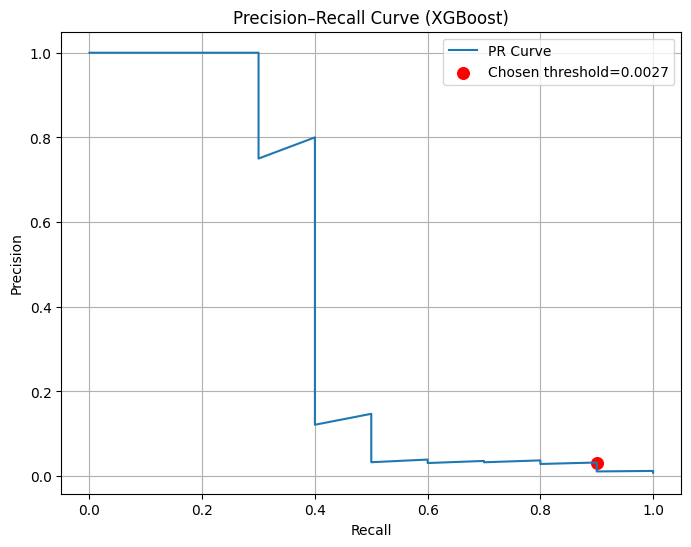

In [53]:
prec, rec, thresh = precision_recall_curve(y_test, y_proba_xgb)

idx = np.argmin(np.abs(thresh - stable_thresh))

plt.figure(figsize=(8, 6))
plt.plot(rec, prec, label="PR Curve")
plt.scatter(rec[idx], prec[idx], color="red", s=70,
            label=f"Chosen threshold={stable_thresh:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (XGBoost)")
plt.legend()
plt.grid(True)
plt.show()

## Risk Stratification Analysis ##

In [56]:
risk_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_proba": y_proba_xgb
}).sort_values("y_proba", ascending=False).reset_index(drop=True)

n = len(risk_df)

top_1p = int(0.01 * n)
top_5p = int(0.05 * n)
top_10p = int(0.10 * n)
top_25p = int(0.25 * n)

strata = {
    "Top 1%": risk_df.iloc[:top_1p],
    "Top 5%": risk_df.iloc[:top_5p],
    "Top 10%": risk_df.iloc[:top_10p],
    "Top 25%": risk_df.iloc[:top_25p],
    "Bottom 75%": risk_df.iloc[top_25p:]
}

print("Risk Stratification Results:")
for name, group in strata.items():
    mortality_rate = group["y_true"].mean()
    print(f"{name:<12}: n={len(group):<4} | Mortality rate = {mortality_rate:.4f}")

Risk Stratification Results:
Top 1%      : n=12   | Mortality rate = 0.3333
Top 5%      : n=63   | Mortality rate = 0.0794
Top 10%     : n=126  | Mortality rate = 0.0397
Top 25%     : n=316  | Mortality rate = 0.0285
Bottom 75%  : n=951  | Mortality rate = 0.0011


## Model Outcomes and Conclusions: ##

From the above results of this notebook, we can see that predicting in-hospital mortality from preoperative characteristics is an extremely tricky task due to the simple fact that nowadays deaths are extremely rare. Despite that however, tuning and optimizing has resulted in the models still capturing some meaningful risk patterns. Initially, the Logistic Regression we used as our baseline performed reasonably well in terms of overall discrimination but struggled with identifying the minority class. It detected only 4 out of 10 deaths and produced many false positives, showing that a simple linear model cannot capture the complexity of perioperative risk in Hospitals. As a result, we switched onto XGBoost, which is much better suited for nonlinear relationships and class imbalances. This model then produced a stronger overall ranking of patients by risk. At the default probability threshold of 0.5, it remained very conservative and detected only 3 deaths, which inflated accuracy but limited clinical usefulness. Once we applied a more appropriate threshold found by tuning using the ROC–Youden method, the model’s behavior changed dramatically: recall increased to 9 out of 10 deaths, which is far more valuable in a clinical screening context. Precision dropped, which is expected when predicting a very rare outcome, but the goal in this domain and for the question we set out to answer, is that it is better to avoid missing high-risk patients rather than to minimize false alarms. The most important insight came from the risk stratification analysis. When we examined how mortality was distributed across predicted risk percentiles, we found that the top 1 percent of patients by model risk had a mortality rate of 33 percent, the top 5 percent had nearly 8 percent, and the top 10 percent had almost 4 percent, while the bottom 75 percent had almost no deaths. This clear separation shows that the model meaningfully concentrates risk in the highest predicted groups, which is exactly what a preoperative risk tool should achieve. Basically, from the initial Logistic Regression which provides a limited baseline, XGBoost combined with proper thresholding and stratification delivers a clinically useful model that identifies the majority of high-risk patients and organizes the population into well-separated risk tiers that could support real-world hospital decision making concerning life and death.